<a href="https://colab.research.google.com/github/sk27110/basic_ml_hse/blob/task_6/homework_06_CNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Основы машинного обучения, ПАДиИИ

## НИУ ВШЭ, 2024-25 учебный год

# Домашнее задание 6: Классификация при помощи CNN

Задание выполнил(а):

    Кочетков Александр
    

## Общая информация

__Внимание!__  


* Домашнее задание выполняется самостоятельно
* Не допускается помощь в решении домашнего задания от однокурсников или третьих лиц. «Похожие» решения считаются плагиатом, и все задействованные студенты — в том числе и те, у кого списали, — не могут получить за него больше 0 баллов
* Использование в решении домашнего задания генеративных моделей (ChatGPT и так далее) за рамками справочной и образовательной информации для генерации кода задания — считается плагиатом, и такое домашнее задание оценивается в 0 баллов
* Старайтесь сделать код как можно более оптимальным. Неэффективная реализация кода может негативно отразиться на оценке. Также оценка может быть снижена за плохо читаемый код и плохо оформленные графики. Все ответы должны сопровождаться кодом или комментариями о том, как они были получены.

## О задании

В этом задании вам предстоит познакомиться со сверточными сетями и их обучением для классификации изображений с использованием библиотеки PyTorch.


## Импорт библиотек

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms

from sklearn.model_selection import train_test_split

## 0. Загрузка данных

Работать мы будем с набором данных [CIFAR10](https://www.cs.toronto.edu/~kriz/cifar.html). CIFAR10 представляет собой набор изображений 32х32 пикселя, разделенных на 10 классов.

![title](https://pytorch.org/tutorials/_images/cifar10.png)




Набор данных уже определен в <code>torchvision.datasets</code>, так что возьмем его оттуда.



In [ ]:
# Для тру нормализации
# mean = [0.4914, 0.4822, 0.4465]
# std = [0.2470, 0.2435, 0.2616]
# Тут взяты значения как в одном из туториалов пайторча :)


def get_cifar10_data(batch_size, transform_train):
    torch.manual_seed(0)
    np.random.seed(0)

    transform_test = transforms.Compose(
        [
            transforms.ToTensor(),
            # Переводим цвета пикселей в отрезок [-1, 1]
            transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)),
        ]
    )

    # Загружаем данные
    trainvalset = torchvision.datasets.CIFAR10(
        root="./data", train=True, download=True, transform=transform_train
    )
    testset = torchvision.datasets.CIFAR10(
        root="./data", train=False, download=True, transform=transform_test
    )

    # В датасете определено разбиение только на train и test,
    # так что валидацию дополнительно выделяем из обучающей выборки
    train_idx, valid_idx = train_test_split(
        np.arange(len(trainvalset)), test_size=0.3, shuffle=True, random_state=0
    )
    trainset = torch.utils.data.Subset(trainvalset, train_idx)
    valset = torch.utils.data.Subset(trainvalset, valid_idx)

    train_loader = torch.utils.data.DataLoader(
        trainset, batch_size=batch_size, shuffle=True, num_workers=2
    )
    val_loader = torch.utils.data.DataLoader(
        valset, batch_size=batch_size, shuffle=False, num_workers=2
    )
    test_loader = torch.utils.data.DataLoader(
        testset, batch_size=batch_size, shuffle=False, num_workers=2
    )

    return train_loader, val_loader, test_loader

In [ ]:
transform = transforms.Compose(
    [transforms.ToTensor(), transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))]
)

train_loader, val_loader, test_loader = get_cifar10_data(
    batch_size=64, transform_train=transform
)

100%|██████████| 170M/170M [00:06<00:00, 27.7MB/s]


Посмотрим на изображения:

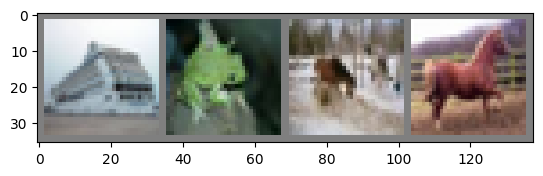

ship frog horse horse


In [ ]:
def imshow(img):
    img = img / 2 + 0.5
    npimg = img.numpy()
    plt.imshow(np.transpose(npimg, (1, 2, 0)))
    plt.show()


dataiter = iter(train_loader)
images, labels = dataiter.__next__()

imshow(torchvision.utils.make_grid(images[:4]))

classes = (
    "plane",
    "car",
    "bird",
    "cat",
    "deer",
    "dog",
    "frog",
    "horse",
    "ship",
    "truck",
)
print(*[classes[labels[i]] for i in range(4)])

## 1. Задание сверточной сети (3 балла)

Теперь нам нужно задать сверточную нейронную сеть, которую мы будем обучать классифицировать изображения.

Используем сеть, основанную на одном блоке архитектуры, похожей на ResNet. Обратите внимание, это не ResNet 1 в 1.

<img src="https://i.ibb.co/2hg962h/basic-block.png" width="500"/>

__Указания:__

- Все сверточные слои должны иметь 32 выходных канала, а также не должны изменять ширину и высоту изображения.
- Выход блока сократите до размерности 32х4х4, применив average pooling.
- Для получения итоговых логитов, распрямите выход пулинга в вектор из 512 элементов, а затем пропустите его через линейный слой.

**Задание 1.1 (3 балла).**

Определите архитектуру сети соответственно схеме и указаниям выше.

Ключевые слова: <code>Conv2d</code>, <code>BatchNorm2d</code>, <code>AvgPool2d</code>.

In [ ]:
n_classes = 10

class BasicBlockNet(nn.Module):
    def __init__(self, n_classes=10):
        super().__init__()

        self.input_conv = nn.Conv2d(3, 32, kernel_size=3, padding=1)
        self.conv1 = nn.Conv2d(32, 32, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(32)
        self.relu = nn.ReLU(inplace=True)
        self.conv2 = nn.Conv2d(32, 32, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(32)
        self.shortcut = nn.Conv2d(32, 32, kernel_size=1)
        self.avgpool = nn.AdaptiveAvgPool2d((4, 4))
        self.fc = nn.Linear(32 * 4 * 4, n_classes)

    def forward(self, x):
        x = self.input_conv(x)
        identity = self.shortcut(x)
        out = self.conv1(x)
        out = self.bn1(out)
        out = self.relu(out)
        out = self.conv2(out)
        out = self.bn2(out)
        out += identity
        out = self.relu(out)
        out = self.avgpool(out)
        out = torch.flatten(out, 1)
        out = self.fc(out)

        return out

In [ ]:
net = BasicBlockNet()
net

BasicBlockNet(
  (input_conv): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv1): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (conv2): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn2): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (shortcut): Conv2d(32, 32, kernel_size=(1, 1), stride=(1, 1))
  (avgpool): AdaptiveAvgPool2d(output_size=(4, 4))
  (fc): Linear(in_features=512, out_features=10, bias=True)
)

Проверим, что выход сети имеет корректную размерность:

In [ ]:
assert net(torch.zeros((10, 3, 32, 32))).shape == (10, 10)

Чтобы проводить вычисления на GPU, в PyTorch необходимо руками перекладывать объекты, с которыми вы хотите проводить вычисления, на графический ускоритель. Это делается следующим образрм:

In [ ]:
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(device)

cuda:0


In [ ]:
net = net.to(device)

Подключение GPU в google.colab:

**Среда выполнения** -> **Сменить среду выполнения** -> **Аппаратный ускоритель** -> **GPU**

## 2. Обучение и тестирование модели (3 балла)

**Задание 2.1 (2 балла).** Переходим к обучению модели. Заполните пропуски в функциях <code>test</code> и <code>train_epoch</code>. В качестве функции потерь будем использовать [кросс-энтропию](https://pytorch.org/docs/stable/generated/torch.nn.functional.cross_entropy.html), а в качестве метрики качества accuracy.

In [ ]:

def test(model, loader):
    loss_log = []
    acc_log = []
    model.eval()

    for data, target in loader:
        data, target = data.to(model.fc.weight.device), target.to(model.fc.weight.device)
        output = model(data)
        loss = F.cross_entropy(output, target)
        loss_log.append(loss.item())

        pred = output.argmax(dim=1)
        acc = (pred == target).float().mean()
        acc_log.append(acc.item())

    return np.mean(loss_log), np.mean(acc_log)


def train_epoch(model, optimizer, train_loader):
    loss_log = []
    acc_log = []
    model.train()

    for data, target in train_loader:
        data, target = data.to(model.fc.weight.device), target.to(model.fc.weight.device)

        optimizer.zero_grad()
        output = model(data)
        loss = F.cross_entropy(output, target)
        loss.backward()
        optimizer.step()

        loss_log.append(loss.item())

        pred = output.argmax(dim=1)
        acc = (pred == target).float().mean()
        acc_log.append(acc.item())
    return loss_log, acc_log


def train(model, optimizer, n_epochs, train_loader, val_loader, scheduler=None):
    train_loss_log, train_acc_log, val_loss_log, val_acc_log = [], [], [], []

    for epoch in range(n_epochs):
        train_loss, train_acc = train_epoch(model, optimizer, train_loader)
        val_loss, val_acc = test(model, val_loader)

        train_loss_log.extend(train_loss)
        train_acc_log.extend(train_acc)

        val_loss_log.append(val_loss)
        val_acc_log.append(val_acc)

        print(f"Epoch {epoch}")
        print(f" train loss: {np.mean(train_loss)}, train acc: {np.mean(train_acc)}")
        print(f" val loss: {val_loss}, val acc: {val_acc}\n")

        if scheduler is not None:
            scheduler.step()

    return train_loss_log, train_acc_log, val_loss_log, val_acc_log

Запустим обучение модели. В качестве оптимизатора будем использовать стохастический градиентный спуск, который является де-факто стандартом в задачах компьютерного зрения (наравне с <code>Adam</code>).

__Замечание:__ Для достижения наилучшего качества в нашем случае потребуется обучать модель несколько сотен эпох. Однако в целях экономии вашего времени и сил, во всех экспериментах мы ограничимся 20 эпохами.

In [ ]:
optimizer = optim.SGD(net.parameters(), lr=0.1, momentum=0.9)
train_loss_log, train_acc_log, val_loss_log, val_acc_log = train(
    net, optimizer, 20, train_loader, val_loader
)

Посчитайте точность на тестовой выборке:

In [ ]:
loss_log, acc_log = test(net, test_loader)
print("Loss func:", loss_log)
print("Accuracy:", acc_log)

Loss func: 0.9325710861546219
Accuracy: 0.6840167197452229


Если вы все сделали правильно, у вас должна была получиться точность $\ge 67\%$.

**Задание 2.2 (1 балл).** Постройте графики зависимости функции потерь и точности классификации от номера шага оптимизатора. На каждом графике расположите данные и для обучающей и для валидационной выборки, итого у вас должно получиться два графика. Обратите внимание, что на обучающей выборке эти данные считаются по каждому батчу, на валидационной же они считаются по всей выборке раз в эпоху.

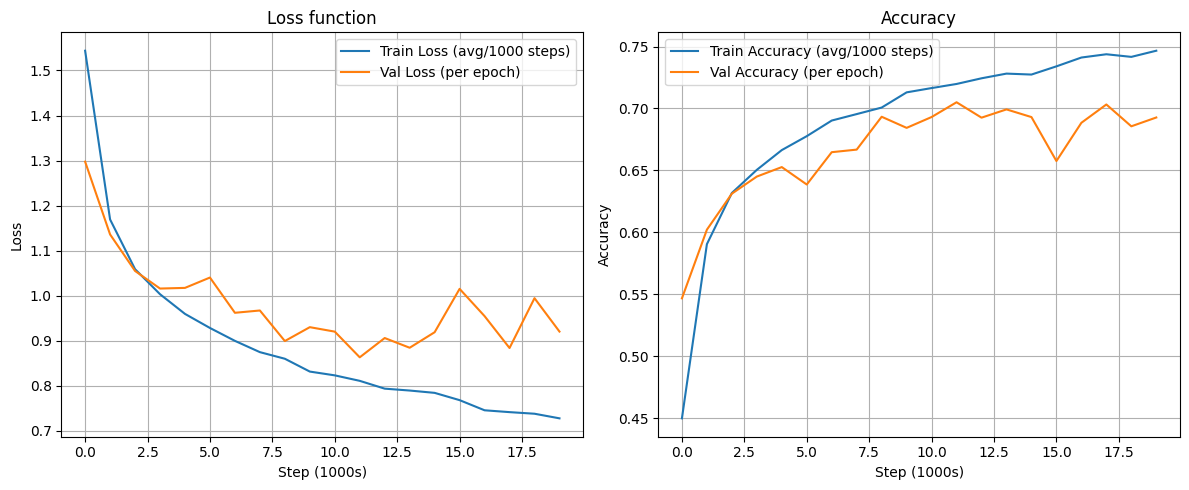

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

def smooth_log(log, window_size=500):
    log = np.array(log)
    num_full_windows = len(log) // window_size
    smoothed = [log[i * window_size:(i + 1) * window_size].mean() for i in range(num_full_windows)]

    if len(log) % window_size != 0:
        smoothed.append(log[num_full_windows * window_size:].mean())

    return smoothed


train_loss_smooth = smooth_log(train_loss_log, window_size=550)
train_acc_smooth = smooth_log(train_acc_log, window_size=550)


plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(train_loss_smooth, label='Train Loss (avg/1000 steps)')
plt.plot(val_loss_log, label='Val Loss (per epoch)')
plt.xlabel('Step (1000s)')
plt.ylabel('Loss')
plt.title('Loss function')
plt.legend()
plt.grid(True)


plt.subplot(1, 2, 2)
plt.plot(train_acc_smooth, label='Train Accuracy (avg/1000 steps)')
plt.plot(val_acc_log, label='Val Accuracy (per epoch)')
plt.xlabel('Step (1000s)')
plt.ylabel('Accuracy')
plt.title('Accuracy')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

## 3. Расписание длины шага (2 балла)

С курса "Машинное обучение" вы уже должны знать, что сходимость стохастического градиентного спуска мы можем теоретически гарантировать только если будем определенным образом со временем уменьшать длину шага. На практике при обучении нейронных сетей такая техника оказывается очень полезной, однако теоретически обоснованными способами уменьшения длины шага фантазия не ограничивается.

Одним из простейших способов является кусочно постоянная функция: на нескольких фиксированных эпохах уменьшаем длину шага в константу раз.

In [ ]:
net = BasicBlockNet().to(device)
optimizer = optim.SGD(net.parameters(), lr=0.1, momentum=0.9)
scheduler = optim.lr_scheduler.MultiStepLR(optimizer, milestones=[10, 15], gamma=0.1)
tr_loss_log, tr_acc_log, val_loss_log, val_acc_log = train(
    net, optimizer, 20, train_loader, val_loader, scheduler
)

Epoch 0
 train loss: 1.5467577679065725, train acc: 0.4450288914021452
 val loss: 1.2654214445580827, val acc: 0.557734929120287

Epoch 1
 train loss: 1.1846804208031956, train acc: 0.5854865826897909
 val loss: 1.10866696378018, val acc: 0.6063829787234043

Epoch 2
 train loss: 1.0714692386238405, train acc: 0.6256284277879341
 val loss: 1.033972400553683, val acc: 0.6463874114320634

Epoch 3
 train loss: 0.9911572372019836, train acc: 0.6540790676416819
 val loss: 1.0715189718185587, val acc: 0.6268838654173181

Epoch 4
 train loss: 0.9495265793320902, train acc: 0.6700346043820355
 val loss: 0.9770613353303138, val acc: 0.668218085106383

Epoch 5
 train loss: 0.9159875465267537, train acc: 0.6813095782966893
 val loss: 1.0193076615637922, val acc: 0.655474290949233

Epoch 6
 train loss: 0.8870217169224671, train acc: 0.6937965200413734
 val loss: 0.9223728989032989, val acc: 0.6868572696726373

Epoch 7
 train loss: 0.8640100783796153, train acc: 0.6995951946300388
 val loss: 0.95874

Посчитайте точность на тестовой выборке:

In [ ]:
loss_log, acc_log = test(net, test_loader)
print("Loss func:", loss_log)
print("Accuracy:", acc_log)

Loss func: 0.7711863096352596
Accuracy: 0.7368630573248408


**Задание 3.0 (0.5 баллов).** Здесь может возникнуть вопрос: а что будет, если мы не будем уменьшать длину шага в процессе обучения, а сразу возьмем констатную, равную значению нашей кусочно-постоянной функции на последних эпохах, то есть $0.001$ в нашем случае. Запустите обучение и проверьте, что в таком случае мы получим худшее качество на тестовой выборке.

In [ ]:
net = BasicBlockNet().to(device)
optimizer = optim.SGD(net.parameters(), lr=0.001, momentum=0.9)

tr_loss_log, tr_acc_log, val_loss_log, val_acc_log = train(
    net, optimizer, 20, train_loader, val_loader
)

Epoch 0
 train loss: 1.7774043765320857, train acc: 0.3833083050560472
 val loss: 1.5448683728563024, val acc: 0.46061613483631864

Epoch 1
 train loss: 1.4893209432988979, train acc: 0.4768501893911763
 val loss: 1.4168268746518073, val acc: 0.5044769503968827

Epoch 2
 train loss: 1.3831131700187975, train acc: 0.5141069796447126
 val loss: 1.3382416091066727, val acc: 0.5273714539852549

Epoch 3
 train loss: 1.306414991453753, train acc: 0.542900398291879
 val loss: 1.2629078241104776, val acc: 0.5582668441407224

Epoch 4
 train loss: 1.2399716209449978, train acc: 0.566507247400894
 val loss: 1.2055256521448177, val acc: 0.57595301422667

Epoch 5
 train loss: 1.1838101996364279, train acc: 0.5890408723838151
 val loss: 1.1821273121427982, val acc: 0.5849955675449777

Epoch 6
 train loss: 1.1309285462447451, train acc: 0.606216538322909
 val loss: 1.115423564961616, val acc: 0.6135416667512122

Epoch 7
 train loss: 1.0849163514822449, train acc: 0.6251060982290961
 val loss: 1.08952

In [ ]:
loss_log, acc_log = test(net, test_loader)
print("Loss func:", loss_log)
print("Accuracy:", acc_log)

Loss func: 0.9027506640762281
Accuracy: 0.6919785031847133


**Задание 3.1 (1.5 балла).** Изучите, какие еще способы уменьшения длины шага представлены в <code>torch.optim.lr_scheduler</code>. Выберите несколько из них, объясните, как они устроены, и обучите модель с ними. Удалось ли добиться улучшения качества на тестовой выборке?

Попробуем ExponentialLR. Работает так: после каждой эпохи lr домнажается на γ, т.е. для эпохи n lr будет равен $lr_0\cdot γ^n$

In [ ]:
net = BasicBlockNet().to(device)
optimizer = optim.SGD(net.parameters(), lr=0.1, momentum=0.9)
scheduler = optim.lr_scheduler.ExponentialLR(optimizer, gamma=0.9)
tr_loss_log, tr_acc_log, val_loss_log, val_acc_log = train(
    net, optimizer, 20, train_loader, val_loader, scheduler
)

Epoch 0
 train loss: 1.582954174421823, train acc: 0.43590852710838945
 val loss: 1.4563366266007118, val acc: 0.48900709228312716

Epoch 1
 train loss: 1.2321944023181142, train acc: 0.5692005093180501
 val loss: 1.1589260362564249, val acc: 0.5986258866939139

Epoch 2
 train loss: 1.07099209864789, train acc: 0.6265914730005769
 val loss: 1.012475791383297, val acc: 0.6462101063829787

Epoch 3
 train loss: 0.9843867543192625, train acc: 0.6591595390597035
 val loss: 0.9884060167251749, val acc: 0.6550088654173182

Epoch 4
 train loss: 0.9292454755502384, train acc: 0.6744091146824782
 val loss: 0.9666620863244889, val acc: 0.6628546100981692

Epoch 5
 train loss: 0.891076097976573, train acc: 0.6905237986575097
 val loss: 0.9102324797752056, val acc: 0.6837101063829787

Epoch 6
 train loss: 0.8638806122421564, train acc: 0.7030597088323869
 val loss: 0.8974730801075063, val acc: 0.6913120569066799

Epoch 7
 train loss: 0.8271024050616695, train acc: 0.712955406204656
 val loss: 0.914

In [ ]:
loss_log, acc_log = test(net, test_loader)
print("------ExponentialLR------")
print("Loss func:", loss_log)
print("Accuracy:", acc_log)

------ExponentialLR------
Loss func: 0.8118969583587282
Accuracy: 0.724422770700637


Теперь попробуем CosineAnnealingLR. Изменяет LR так: $LR = η_{min} + 0.5*(η_{max} - η_{min})*(1 + cos(π * t/T_{max}))$

$η_{max}$ - начальный lr

In [ ]:
net = BasicBlockNet().to(device)
optimizer = optim.SGD(net.parameters(), lr=0.1, momentum=0.9)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=20, eta_min=0.001)
tr_loss_log, tr_acc_log, val_loss_log, val_acc_log = train(
    net, optimizer, 20, train_loader, val_loader, scheduler
)

Epoch 0
 train loss: 1.4923723257219987, train acc: 0.46739928835706696
 val loss: 1.263380629458326, val acc: 0.5564273050490846

Epoch 1
 train loss: 1.1390493264799797, train acc: 0.6028622029250457
 val loss: 1.078622378947887, val acc: 0.6190159574468085

Epoch 2
 train loss: 1.031021940751747, train acc: 0.6413554453326753
 val loss: 0.9873753385340914, val acc: 0.6558289007937654

Epoch 3
 train loss: 0.9694475450942895, train acc: 0.6618895273539877
 val loss: 0.9886560911827899, val acc: 0.658222517815042

Epoch 4
 train loss: 0.9161560682535608, train acc: 0.6808198943216578
 val loss: 1.0101757528934072, val acc: 0.6525709220703612

Epoch 5
 train loss: 0.8771302035347417, train acc: 0.6960164208298846
 val loss: 0.947327845654589, val acc: 0.6775487590343394

Epoch 6
 train loss: 0.845028415022646, train acc: 0.7086217028567299
 val loss: 0.8952089071273803, val acc: 0.6933953901554676

Epoch 7
 train loss: 0.8068978344609576, train acc: 0.7193661857348691
 val loss: 0.9258

In [ ]:
loss_log, acc_log = test(net, test_loader)
print("------CosineAnnealingLR------")
print("Loss func:", loss_log)
print("Accuracy:", acc_log)

------CosineAnnealingLR------
Loss func: 0.7411889133939318
Accuracy: 0.743531050955414


На самом деле результаты такие, я случайно перезапустил ячейку)

Loss func: 0.7515884472686014

Accuracy: 0.7500995222929936

Your answers here:  
При использовании CosineAnnealingLR accuracy на тесте сильно вырасла.

## 4. Аугментации данных (2 балла)

Еще одной стандартной техникой, применяющейся в глубинном обучении, а особенно часто в компьютерном зрении, являются аугментации данных. Суть аугментаций состоит в том, что мы можем некоторым синтетическим образом видоизменять объекты обучающей выборки, тем самым расширяя ее, а также делая итоговую модель более устойчивой к таким изменениям.

Простейшая аугментация, которую можно применить к картинкам — разворот картинки по горизонтальной оси. То есть при обучении модели с вероятностью $0.5$ мы будем разворачивать картинку из обучающей выборки.

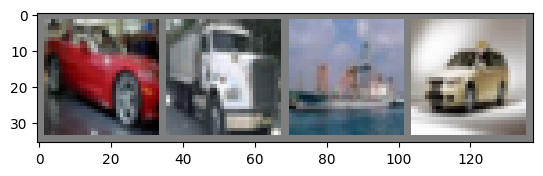

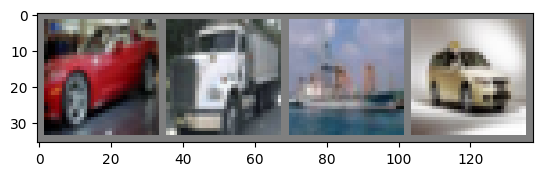

In [ ]:
dataiter = iter(train_loader)
images, labels = dataiter.__next__()

imshow(torchvision.utils.make_grid(images[:4]))

imshow(torchvision.utils.make_grid(transforms.functional.hflip(images[:4])))

Наиболее удобным способом работы с аугментациями в PyTorch является их задание в списке <code>transforms</code>, который затем передается в загрузчик данных. Обучим нашу сеть, применяя горизонтальные повороты:

In [ ]:
transform = transforms.Compose(
    [
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
        transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)),
    ]
)

train_loader, val_loader, test_loader = get_cifar10_data(
    batch_size=64, transform_train=transform
)

net = BasicBlockNet().to(device)
optimizer = optim.SGD(net.parameters(), lr=0.1, momentum=0.9)
scheduler = optim.lr_scheduler.MultiStepLR(optimizer, milestones=[10, 15], gamma=0.1)
tr_loss_log, tr_acc_log, val_loss_log, val_acc_log = train(
    net, optimizer, 20, train_loader, val_loader, scheduler
)

Epoch 0
 train loss: 1.4978707374994673, train acc: 0.46782776184884023
 val loss: 1.3615010147399091, val acc: 0.5252216312479465

Epoch 1
 train loss: 1.1596285735667298, train acc: 0.5952149713497057
 val loss: 1.0839362760807605, val acc: 0.6266622340425532

Epoch 2
 train loss: 1.0558320867949909, train acc: 0.6329859297933701
 val loss: 1.0470767513234565, val acc: 0.6306959220703612

Epoch 3
 train loss: 1.000488716570943, train acc: 0.6536873205270366
 val loss: 1.0074278948154856, val acc: 0.6531914893617021

Epoch 4
 train loss: 0.958247963536592, train acc: 0.6688512014514567
 val loss: 0.9985353439412219, val acc: 0.6573138297872341

Epoch 5
 train loss: 0.9205755583764866, train acc: 0.6837294333813613
 val loss: 0.9051860933608197, val acc: 0.688253546268382

Epoch 6
 train loss: 0.8958242127511793, train acc: 0.6899320972467036
 val loss: 0.8953527271747589, val acc: 0.691378546268382

Epoch 7
 train loss: 0.8741237986458285, train acc: 0.6977670410651393
 val loss: 0.93

Посчитайте точность на тестовой выборке:

In [ ]:
loss_log, acc_log = test(net, test_loader)
print("Loss func:", loss_log)
print("Accuracy:", acc_log)

Loss func: 0.7411889133939318
Accuracy: 0.743531050955414


**Задание 4.1 (2 балла).** Изучите, какие еще способы аугментаций изображений представлены в <code>torchvision.transforms</code>. Выберите несколько из них, объясните, как они устроены, и обучите модель с ними (по отдельности и вместе). Удалось ли добиться улучшения качества на тестовой выборке?

Для начала используем RandomCrop. Он добавляет по 4 пикселя с каждой стороны изображения и затем случайно вырезает область 32*32 пикселя. Так модель учится распознавать изображение в разных частях кадра.

In [ ]:
transform_geo = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

train_loader, val_loader, test_loader = get_cifar10_data(
    batch_size=64, transform_train=transform_geo
)

net = BasicBlockNet().to(device)
optimizer = optim.SGD(net.parameters(), lr=0.1, momentum=0.9)
scheduler = optim.lr_scheduler.MultiStepLR(optimizer, milestones=[10, 15], gamma=0.1)
tr_loss_log, tr_acc_log, val_loss_log, val_acc_log = train(
    net, optimizer, 20, train_loader, val_loader, scheduler
)

Epoch 0
 train loss: 1.6928864593261774, train acc: 0.3841285257714322
 val loss: 1.5255659894740328, val acc: 0.44878102845333995

Epoch 1
 train loss: 1.425746090233435, train acc: 0.4914427723265653
 val loss: 1.370787410025901, val acc: 0.5178413122258287

Epoch 2
 train loss: 1.2834567300144453, train acc: 0.5480216767713836
 val loss: 1.3177563190460204, val acc: 0.5309397163543296

Epoch 3
 train loss: 1.1949099603039255, train acc: 0.579508357335706
 val loss: 1.2005397056011444, val acc: 0.5826241135597229

Epoch 4
 train loss: 1.143158011288268, train acc: 0.5989732959152794
 val loss: 1.1396656292550107, val acc: 0.6049645390916378

Epoch 5
 train loss: 1.1130576948797026, train acc: 0.6109664730005769
 val loss: 1.1288458146947495, val acc: 0.6046099292471053

Epoch 6
 train loss: 1.0814445133183077, train acc: 0.6203969705039448
 val loss: 1.0995769330795775, val acc: 0.6159131207364671

Epoch 7
 train loss: 1.049376131302696, train acc: 0.6335245821985945
 val loss: 1.046

In [ ]:
loss_log, acc_log = test(net, test_loader)
print("Loss func:", loss_log)
print("Accuracy:", acc_log)

Loss func: 0.8123116869076042
Accuracy: 0.7184514331210191


Результат хуже чем раньше.

Теперь используем ColorJitter. Он случайным образом меняет параметры цвета (яркость, контрасность, насыщенность)

In [ ]:
transform_color = transforms.Compose([
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.3),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

train_loader, val_loader, test_loader = get_cifar10_data(
    batch_size=64, transform_train=transform_color
)

net = BasicBlockNet().to(device)
optimizer = optim.SGD(net.parameters(), lr=0.1, momentum=0.9)
scheduler = optim.lr_scheduler.MultiStepLR(optimizer, milestones=[10, 15], gamma=0.1)
tr_loss_log, tr_acc_log, val_loss_log, val_acc_log = train(
    net, optimizer, 20, train_loader, val_loader, scheduler
)

Epoch 0
 train loss: 1.548061630516645, train acc: 0.44930546495116824
 val loss: 1.3814203622493337, val acc: 0.5105718085106383

Epoch 1
 train loss: 1.2079503137407182, train acc: 0.5786228454527079
 val loss: 1.0970311258701568, val acc: 0.6198359930768926

Epoch 2
 train loss: 1.0945648474710732, train acc: 0.6200133847580096
 val loss: 1.079966831460912, val acc: 0.6273492908224146

Epoch 3
 train loss: 1.0312439735018575, train acc: 0.6430366937159621
 val loss: 1.0780140268041734, val acc: 0.6306072696726372

Epoch 4
 train loss: 0.9863534504360429, train acc: 0.6616773308957953
 val loss: 1.0630283667686138, val acc: 0.6310283688788718

Epoch 5
 train loss: 0.9547988081545019, train acc: 0.6725115892656106
 val loss: 0.9705519536708264, val acc: 0.6648049646235527

Epoch 6
 train loss: 0.9220906050375218, train acc: 0.6820400235203982
 val loss: 0.9558349797066222, val acc: 0.6731826241980208

Epoch 7
 train loss: 0.9054668553350612, train acc: 0.6902177462412191
 val loss: 0.

Тут результаты получше

In [ ]:
loss_log, acc_log = test(net, test_loader)
print("Loss func:", loss_log)
print("Accuracy:", acc_log)

Loss func: 0.7733922710843907
Accuracy: 0.7339769108280255


Теперь соберем все вместе:

In [ ]:
transform_both = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.3),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])


train_loader, val_loader, test_loader = get_cifar10_data(
    batch_size=64, transform_train=transform_both
)

net = BasicBlockNet().to(device)
optimizer = optim.SGD(net.parameters(), lr=0.1, momentum=0.9)
scheduler = optim.lr_scheduler.MultiStepLR(optimizer, milestones=[10, 15], gamma=0.1)
tr_loss_log, tr_acc_log, val_loss_log, val_acc_log = train(
    net, optimizer, 20, train_loader, val_loader, scheduler
)

Epoch 0
 train loss: 1.7658583265771814, train acc: 0.3559064051132969
 val loss: 1.6359861942047769, val acc: 0.40711436170212767

Epoch 1
 train loss: 1.4747564546368894, train acc: 0.47425078354108485
 val loss: 1.524742981728087, val acc: 0.4821808510638298

Epoch 2
 train loss: 1.3225525769062845, train acc: 0.5370445939043105
 val loss: 1.2722546709344742, val acc: 0.5494902482692231

Epoch 3
 train loss: 1.258634915844396, train acc: 0.558166296706557
 val loss: 1.2707440525927443, val acc: 0.5502437944107867

Epoch 4
 train loss: 1.20550870612073, train acc: 0.5790105118829981
 val loss: 1.1884487076008574, val acc: 0.5825576241980208

Epoch 5
 train loss: 1.1733175654515924, train acc: 0.589771317607524
 val loss: 1.1949189858233675, val acc: 0.5914228723404256

Epoch 6
 train loss: 1.1498509306576397, train acc: 0.5977776508226691
 val loss: 1.264657831952927, val acc: 0.5665780143534883

Epoch 7
 train loss: 1.1201298074486923, train acc: 0.6105747257769653
 val loss: 1.1098

Результат лучше не стал

In [ ]:
loss_log, acc_log = test(net, test_loader)
print("Loss func:", loss_log)
print("Accuracy:", acc_log)

Loss func: 0.8139164599643391
Accuracy: 0.7209394904458599


## Бонус. Логирование в wandb (1 балл)

На практике специалиста по глубинному обучению часто встречаются ситуации, когда нейросеть учится на каком-то удаленном сервере. И обычно вам хочется отслеживать прогресс обучения, особенно когда время обучения модели исчисляется днями или неделями. Для таких целей существует несколько инструментов. Вероятно, самый популярный из них — [wandb](https://wandb.ai/site).

Ваша задача состоит в том, чтобы разобраться как им пользоваться, и повторить задания 2.1 и 2.2 с его использованием. Обучение вы можете запускать в этом же ноутбуке, но теперь вам необходимо через wandb логировать значения функции потерь и точности на обучающей выборке и на валидационной. Результатом работы должны быть ваш код и публичная ссылка на страничку с графиками, идентичными графикам в задании 2.2.

Если вас смущает, что WandB грозится забанить вас, то можете разобраться с любым его аналогом и приложить ссылку на аналог.

In [ ]:
# <your code here>

Ссылка на страницу с графиками:

    (...)